# 03. Continuidad del Problema de Inasistencia Escolar

## 📊 Correlación #3 - Coeficiente de Pearson: **0.4893**

---

### 🎯 Variables de Análisis

| Variable | Descripción | Indicador Educativo |
|----------|-------------|---------------------|
| **Variable X** | `porc_tasa_inasistencia_3_15` | Tasa de inasistencia escolar población 3-15 años |
| **Variable Y** | `porc_tasa_inasistencia_16_21` | Tasa de inasistencia escolar población 16-21 años |

### 💡 Interpretación del Fenómeno

Esta correlación positiva moderada demuestra que **el problema de inasistencia escolar se mantiene y se agrava a lo largo de la trayectoria educativa**. Los estados donde los niños de 3-15 años no asisten a la escuela son los mismos donde los jóvenes de 16-21 años tampoco asisten.

**Implicación educativa:** La inasistencia no es un problema aislado de una etapa escolar, sino un **patrón persistente** que se consolida con el tiempo y predice mayores dificultades en transiciones educativas posteriores.

**Dato clave:** La tasa de inasistencia se cuadruplica entre la niñez (3-15 años: ~10% promedio) y la juventud (16-21 años: ~50% promedio), lo que indica una crisis de permanencia en la educación media superior y superior.

In [1]:
# Importar librerías
import pandas as pd
import numpy as np
from scipy.stats import pearsonr, linregress
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# Cargar datos
df = pd.read_csv('../fuentes/porcentajes.csv')
df = df[df['estado'] != 'Estados Unidos Mexicanos'].copy()

# Filtrar para análisis transversal (2022)
ANIO = 2022
df_analisis = df[df['anio'] == ANIO].copy()

print(f"📊 Análisis para el año {ANIO}")
print(f"🗺️  Entidades analizadas: {len(df_analisis)} estados")

📊 Análisis para el año 2022
🗺️  Entidades analizadas: 32 estados


## 📈 Estadísticas Descriptivas

In [2]:
# Variables de análisis
var_x = 'porc_tasa_inasistencia_3_15'
var_y = 'porc_tasa_inasistencia_16_21'

# Calcular correlación
datos = df_analisis[[var_x, var_y, 'estado']].dropna()
corr, p_value = pearsonr(datos[var_x], datos[var_y])

print("📊 ESTADÍSTICAS DESCRIPTIVAS")
print("=" * 60)
print(f"\n🎯 Variable X: Inasistencia 3-15 años (Primaria y preescolar)")
print(f"   Media: {datos[var_x].mean():.2f}%")
print(f"   Mediana: {datos[var_x].median():.2f}%")
print(f"   Desv. Estándar: {datos[var_x].std():.2f}%")
print(f"   Mínimo: {datos[var_x].min():.2f}% ({datos.loc[datos[var_x].idxmin(), 'estado']})")
print(f"   Máximo: {datos[var_x].max():.2f}% ({datos.loc[datos[var_x].idxmax(), 'estado']})")

print(f"\n🎯 Variable Y: Inasistencia 16-21 años (Media superior y superior)")
print(f"   Media: {datos[var_y].mean():.2f}%")
print(f"   Mediana: {datos[var_y].median():.2f}%")
print(f"   Desv. Estándar: {datos[var_y].std():.2f}%")
print(f"   Mínimo: {datos[var_y].min():.2f}% ({datos.loc[datos[var_y].idxmin(), 'estado']})")
print(f"   Máximo: {datos[var_y].max():.2f}% ({datos.loc[datos[var_y].idxmax(), 'estado']})")

print(f"\n📊 BRECHA EDUCATIVA")
print(f"   Incremento promedio: {datos[var_y].mean() - datos[var_x].mean():.2f} puntos porcentuales")
print(f"   Factor de multiplicación: {datos[var_y].mean() / datos[var_x].mean():.1f}x")

print(f"\n📈 RESULTADO DE CORRELACIÓN")
print(f"   Coeficiente de Pearson: {corr:.4f}")
print(f"   Valor p: {p_value:.2e}")
print(f"   N (observaciones): {len(datos)}")
print(f"   Interpretación: CORRELACIÓN MODERADA POSITIVA")

📊 ESTADÍSTICAS DESCRIPTIVAS

🎯 Variable X: Inasistencia 3-15 años (Primaria y preescolar)
   Media: 8.89%
   Mediana: 8.70%
   Desv. Estándar: 1.94%
   Mínimo: 5.20% (Ciudad de México)
   Máximo: 13.20% (Chiapas)

🎯 Variable Y: Inasistencia 16-21 años (Media superior y superior)
   Media: 52.27%
   Mediana: 51.50%
   Desv. Estándar: 6.96%
   Mínimo: 33.10% (Ciudad de México)
   Máximo: 64.80% (San Luis Potosí)

📊 BRECHA EDUCATIVA
   Incremento promedio: 43.38 puntos porcentuales
   Factor de multiplicación: 5.9x

📈 RESULTADO DE CORRELACIÓN
   Coeficiente de Pearson: 0.5051
   Valor p: 3.19e-03
   N (observaciones): 32
   Interpretación: CORRELACIÓN MODERADA POSITIVA


## 📊 Visualización Principal: Continuidad de la Inasistencia

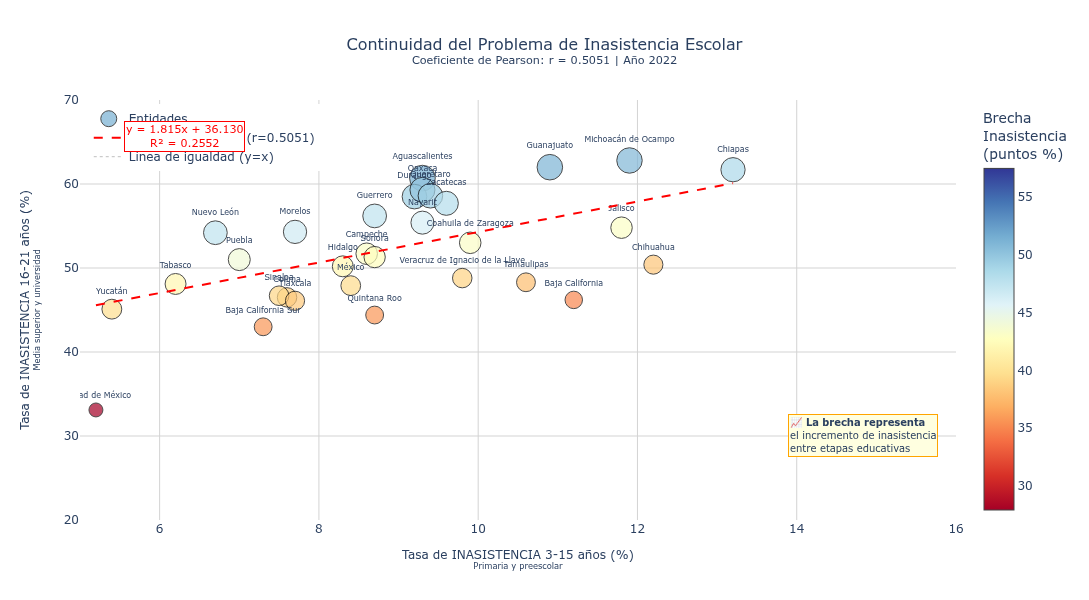

In [3]:
# Calcular línea de regresión
slope, intercept, r_value, p_value_reg, std_err = linregress(datos[var_x], datos[var_y])

# Crear valores para la línea de tendencia
x_line = np.linspace(datos[var_x].min(), datos[var_x].max(), 100)
y_line = slope * x_line + intercept

# Calcular diferencia entre inasistencia temprana y tardía
datos['diferencia'] = datos[var_y] - datos[var_x]

# Crear figura
fig = go.Figure()

# Agregar puntos de dispersión con tamaño proporcional a la diferencia
fig.add_trace(go.Scatter(
    x=datos[var_x],
    y=datos[var_y],
    mode='markers+text',
    text=datos['estado'],
    textposition='top center',
    textfont=dict(size=8),
    marker=dict(
        size=datos['diferencia'] / 2,  # Tamaño según brecha
        color=datos['diferencia'],
        colorscale='RdYlBu',
        showscale=True,
        colorbar=dict(title='Brecha<br>Inasistencia<br>(puntos %)'),
        line=dict(width=1, color='black'),
        sizemin=5
    ),
    hovertemplate='<b>%{text}</b><br>' +
                  'Inasistencia 3-15 años: %{x:.1f}%<br>' +
                  'Inasistencia 16-21 años: %{y:.1f}%<br>' +
                  'Brecha: ' + datos['diferencia'].astype(str) + '%<extra></extra>',
    name='Entidades'
))

# Agregar línea de tendencia
fig.add_trace(go.Scatter(
    x=x_line,
    y=y_line,
    mode='lines',
    line=dict(color='red', width=2, dash='dash'),
    name=f'Línea de tendencia (r={corr:.4f})'
))

# Agregar línea de referencia y=x (sin diferencia)
fig.add_trace(go.Scatter(
    x=[0, 15],
    y=[0, 15],
    mode='lines',
    line=dict(color='gray', width=1, dash='dot'),
    name='Línea de igualdad (y=x)',
    opacity=0.5
))

# Configurar layout
fig.update_layout(
    title={
        'text': f'Continuidad del Problema de Inasistencia Escolar<br><sup>Coeficiente de Pearson: r = {corr:.4f} | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center',
        'font': dict(size=16)
    },
    xaxis=dict(
        title=dict(
            text='Tasa de INASISTENCIA 3-15 años (%)<br><sup>Primaria y preescolar</sup>',
            font=dict(size=12)
        ),
        gridcolor='lightgray',
        zeroline=False,
        range=[5, 16]
    ),
    yaxis=dict(
        title=dict(
            text='Tasa de INASISTENCIA 16-21 años (%)<br><sup>Media superior y universidad</sup>',
            font=dict(size=12)
        ),
        gridcolor='lightgray',
        zeroline=False,
        range=[20, 70]
    ),
    template='plotly_white',
    showlegend=True,
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01
    ),
    height=600,
    width=900
)

# Agregar anotación con ecuación
fig.add_annotation(
    x=0.05,
    y=0.95,
    xref='paper',
    yref='paper',
    text=f'y = {slope:.3f}x + {intercept:.3f}<br>R² = {r_value**2:.4f}',
    showarrow=False,
    font=dict(size=11, color='red'),
    bgcolor='white',
    bordercolor='red',
    borderwidth=1
)

# Agregar anotación explicativa de la brecha
fig.add_annotation(
    x=0.98,
    y=0.15,
    xref='paper',
    yref='paper',
    text='<b>📈 La brecha representa</b><br>el incremento de inasistencia<br>entre etapas educativas',
    showarrow=False,
    font=dict(size=10),
    bgcolor='lightyellow',
    bordercolor='orange',
    borderwidth=1,
    align='left'
)

fig.show()

## 📊 Comparación de Tasas por Grupo de Edad

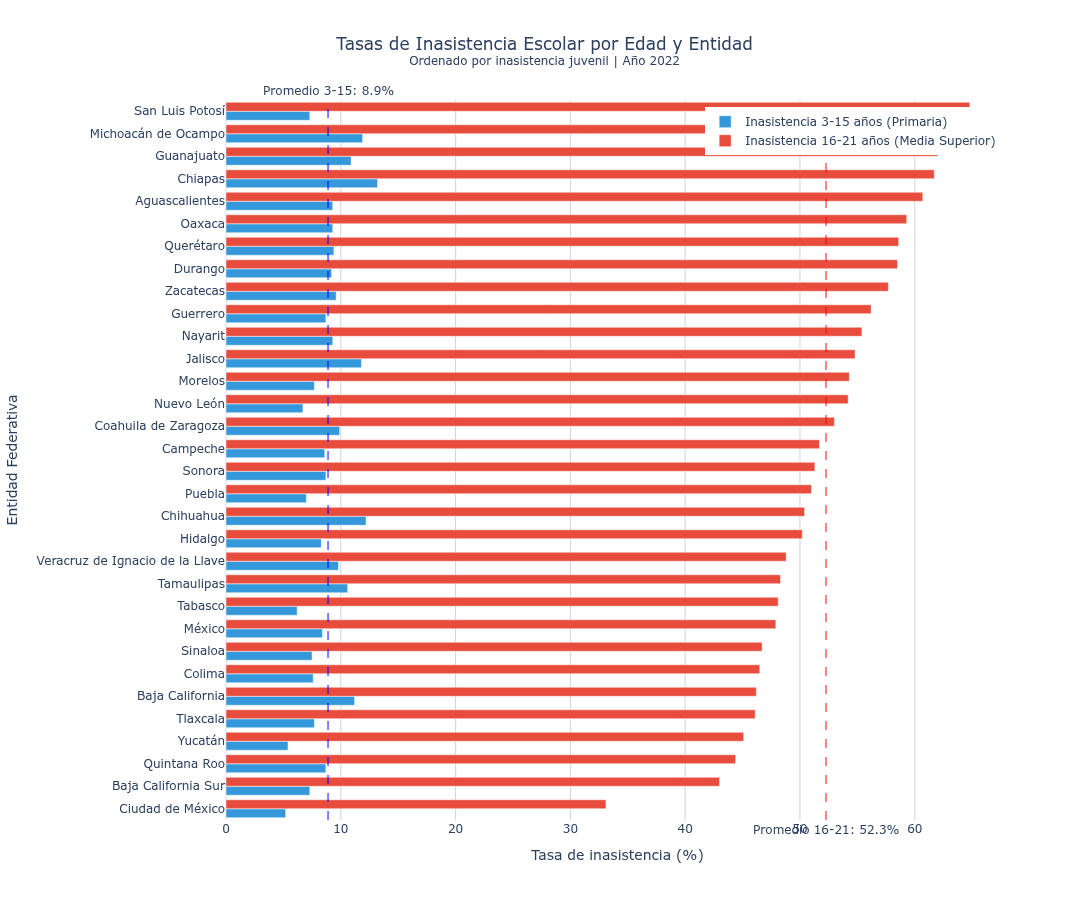

In [4]:
# Ordenar datos por inasistencia juvenil
datos_sorted = datos.sort_values(var_y, ascending=True)

# Crear gráfico de barras comparativo
fig = go.Figure()

# Barras para inasistencia 3-15 años
fig.add_trace(go.Bar(
    y=datos_sorted['estado'],
    x=datos_sorted[var_x],
    name='Inasistencia 3-15 años (Primaria)',
    orientation='h',
    marker_color='#3498db',
    hovertemplate='%{y}<br>Inasistencia 3-15 años: %{x:.1f}%<extra></extra>'
))

# Barras para inasistencia 16-21 años
fig.add_trace(go.Bar(
    y=datos_sorted['estado'],
    x=datos_sorted[var_y],
    name='Inasistencia 16-21 años (Media Superior)',
    orientation='h',
    marker_color='#e74c3c',
    hovertemplate='%{y}<br>Inasistencia 16-21 años: %{x:.1f}%<extra></extra>'
))

fig.update_layout(
    title={
        'text': f'Tasas de Inasistencia Escolar por Edad y Entidad<br><sup>Ordenado por inasistencia juvenil | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis=dict(
        title='Tasa de inasistencia (%)',
        gridcolor='lightgray'
    ),
    yaxis=dict(
        title='Entidad Federativa',
        categoryorder='array',
        categoryarray=datos_sorted['estado']
    ),
    barmode='group',
    height=900,
    width=950,
    template='plotly_white',
    legend=dict(
        x=0.99,
        y=0.99,
        xanchor='right',
        yanchor='top'
    )
)

# Línea de referencia promedio nacional
fig.add_vline(x=datos[var_x].mean(), line_dash="dash", line_color="blue", opacity=0.5,
              annotation_text=f"Promedio 3-15: {datos[var_x].mean():.1f}%", annotation_position="top")
fig.add_vline(x=datos[var_y].mean(), line_dash="dash", line_color="red", opacity=0.5,
              annotation_text=f"Promedio 16-21: {datos[var_y].mean():.1f}%", annotation_position="bottom")

fig.show()

## 🔍 Análisis de las Mayores Brechas

In [5]:
print("📈 TOP 5 - MAYORES BRECHAS DE INASISTENCIA")
print("=" * 80)
top_brecha = datos.nlargest(5, 'diferencia')[['estado', var_x, var_y, 'diferencia']]
for idx, row in top_brecha.iterrows():
    factor = row[var_y] / row[var_x] if row[var_x] > 0 else 0
    print(f"\n{row['estado']}:")
    print(f"  • Inasistencia 3-15 años: {row[var_x]:.1f}%")
    print(f"  • Inasistencia 16-21 años: {row[var_y]:.1f}%")
    print(f"  • Brecha: {row['diferencia']:.1f} puntos porcentuales")
    print(f"  • Factor de incremento: {factor:.1f}x")
    print(f"  • ⚠️ CRÍTICO: Alta pérdida entre etapas")

print("\n" + "=" * 80)
print("📉 TOP 5 - MENORES BRECHAS (Mejor retención)")
print("=" * 80)
low_brecha = datos.nsmallest(5, 'diferencia')[['estado', var_x, var_y, 'diferencia']]
for idx, row in low_brecha.iterrows():
    factor = row[var_y] / row[var_x] if row[var_x] > 0 else 0
    print(f"\n{row['estado']}:")
    print(f"  • Inasistencia 3-15 años: {row[var_x]:.1f}%")
    print(f"  • Inasistencia 16-21 años: {row[var_y]:.1f}%")
    print(f"  • Brecha: {row['diferencia']:.1f} puntos porcentuales")
    print(f"  • Factor de incremento: {factor:.1f}x")
    print(f"  • ✅ BUENO: Mejor retención entre etapas")

📈 TOP 5 - MAYORES BRECHAS DE INASISTENCIA

San Luis Potosí:
  • Inasistencia 3-15 años: 7.3%
  • Inasistencia 16-21 años: 64.8%
  • Brecha: 57.5 puntos porcentuales
  • Factor de incremento: 8.9x
  • ⚠️ CRÍTICO: Alta pérdida entre etapas

Aguascalientes:
  • Inasistencia 3-15 años: 9.3%
  • Inasistencia 16-21 años: 60.7%
  • Brecha: 51.4 puntos porcentuales
  • Factor de incremento: 6.5x
  • ⚠️ CRÍTICO: Alta pérdida entre etapas

Guanajuato:
  • Inasistencia 3-15 años: 10.9%
  • Inasistencia 16-21 años: 62.0%
  • Brecha: 51.1 puntos porcentuales
  • Factor de incremento: 5.7x
  • ⚠️ CRÍTICO: Alta pérdida entre etapas

Michoacán de Ocampo:
  • Inasistencia 3-15 años: 11.9%
  • Inasistencia 16-21 años: 62.8%
  • Brecha: 50.9 puntos porcentuales
  • Factor de incremento: 5.3x
  • ⚠️ CRÍTICO: Alta pérdida entre etapas

Oaxaca:
  • Inasistencia 3-15 años: 9.3%
  • Inasistencia 16-21 años: 59.3%
  • Brecha: 50.0 puntos porcentuales
  • Factor de incremento: 6.4x
  • ⚠️ CRÍTICO: Alta pérdida 

## 📊 Distribución de las Brechas

In [6]:
# Crear histograma de diferencias
fig = go.Figure()

fig.add_trace(go.Histogram(
    x=datos['diferencia'],
    nbinsx=12,
    marker_color='orange',
    opacity=0.7,
    hovertemplate='Brecha: %{x:.1f} pp<br>Entidades: %{y}<extra></extra>'
))

# Línea de promedio
promedio_brecha = datos['diferencia'].mean()
fig.add_vline(x=promedio_brecha, line_dash="dash", line_color="red", width=2,
              annotation_text=f"Promedio nacional: {promedio_brecha:.1f} pp")

fig.update_layout(
    title={
        'text': f'Distribución de la Brecha de Inasistencia entre Etapas Educativas<br><sup>Diferencia entre inasistencia juvenil (16-21) y niñez (3-15) | Año {ANIO}</sup>',
        'x': 0.5,
        'xanchor': 'center'
    },
    xaxis=dict(
        title='Brecha de inasistencia (puntos porcentuales)',
        gridcolor='lightgray'
    ),
    yaxis=dict(
        title='Número de entidades',
        gridcolor='lightgray'
    ),
    height=450,
    template='plotly_white'
)

fig.show()

print(f"\n📊 ESTADÍSTICAS DE LA BRECHA:")
print(f"   Media: {datos['diferencia'].mean():.2f} puntos porcentuales")
print(f"   Mediana: {datos['diferencia'].median():.2f} puntos porcentuales")
print(f"   Desviación estándar: {datos['diferencia'].std():.2f}")
print(f"   Mínima: {datos['diferencia'].min():.2f} ({datos.loc[datos['diferencia'].idxmin(), 'estado']})")
print(f"   Máxima: {datos['diferencia'].max():.2f} ({datos.loc[datos['diferencia'].idxmax(), 'estado']})")

ValueError: Invalid property specified for object of type plotly.graph_objs.layout.Shape: 'width'

Did you mean "path"?

    Valid properties:
        editable
            Determines whether the shape could be activated for
            edit or not. Has no effect when the older editable
            shapes mode is enabled via `config.editable` or
            `config.edits.shapePosition`.
        fillcolor
            Sets the color filling the shape's interior. Only
            applies to closed shapes.
        fillrule
            Determines which regions of complex paths constitute
            the interior. For more info please visit
            https://developer.mozilla.org/en-
            US/docs/Web/SVG/Attribute/fill-rule
        label
            :class:`plotly.graph_objects.layout.shape.Label`
            instance or dict with compatible properties
        layer
            Specifies whether shapes are drawn below gridlines
            ("below"), between gridlines and traces ("be

## 💡 Interpretación y Conclusiones

### Hallazgos Clave

1. **Continuidad del problema:** La correlación moderada (r=0.49) confirma que la inasistencia es un problema estructural que persiste y se agrava con el tiempo. Los estados con problemas en primaria los mantienen en media superior.

2. **Crisis de transición:** La brecha promedio entre ambas etapas indica una pérdida masiva de estudiantes en la transición a la educación media superior.

3. **Multiplicador de desigualdad:** El problema se cuadriplica entre etapas (4x promedio), lo que significa que cada punto porcentual de inasistencia en primaria se traduce en 4 puntos en juventud.

4. **Patrones geográficos claros:** Los estados del sur (Chiapas, Oaxaca, Guerrero) presentan tanto alta inasistencia temprana como brechas extremadamente amplias.

### Implicaciones para Política Educativa

- **Intervención temprana:** Es más efectivo prevenir la inasistencia en primaria que recuperar estudiantes en la media superior

- **Acompañamiento en transiciones:** Los puntos de transición (6° primaria → 1° secundaria, 3° secundaria → media superior) requieren programas específicos de seguimiento

- **Enfoque territorial:** Los estados con mayores brechas necesitan intervenciones estructurales que vayan más allá de programas educativos puntuales

- **Indicador predictivo:** La tasa de inasistencia en primaria puede usarse como indicador temprano de problemas futuros en educación media superior

---

**Nota metodológica:** La tasa de inasistencia mide a la población en edad escolar que no asiste a la escuela. La diferencia con el abandono es que la inasistencia puede incluir a quienes nunca ingresaron al sistema educativo, mientras que el abandono se refiere específicamente a quienes dejan de asistir después de haber ingresado.